
--- K-Means Clustering ---


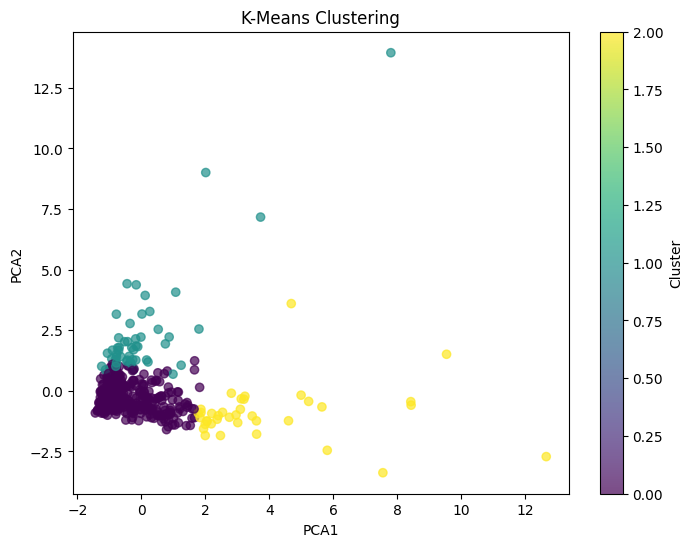

Cluster Summaries:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        1.282857  2.534286   8935.500000   4228.528571   5848.034286   
1        1.113208  2.698113  34540.113208   5860.358491   6122.622642   
2        2.000000  2.405405   8704.864865  20534.405405  30466.243243   

              Frozen  Detergents_Paper  Delicatessen  
Cluster                                               
0        2167.231429       1913.605714   1102.120000  
1        9841.735849        981.471698   3664.245283  
2        1932.621622      14758.837838   2459.351351  
Cluster Sizes:
0    350
1     53
2     37
Name: count, dtype: int64
Feature Variance Across Clusters:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        0.203430  0.610569  5.290787e+07  1.402581e+07  2.556984e+07   
1        0.102322  

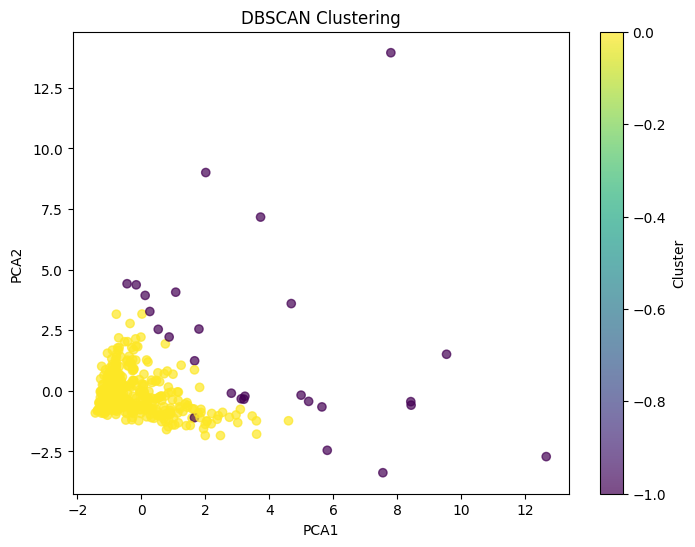

Cluster Sizes:
 0    413
-1     27
Name: count, dtype: int64

--- Hierarchical Clustering ---


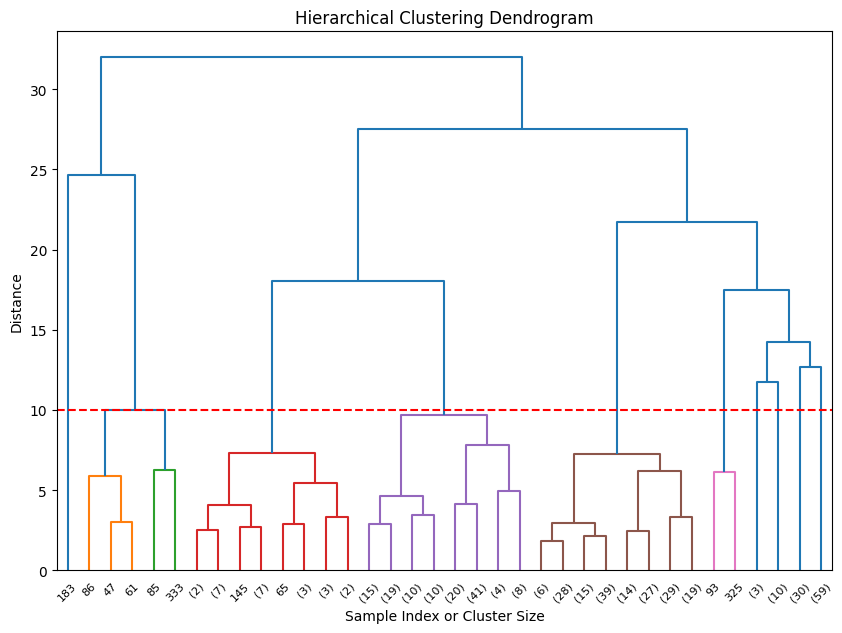

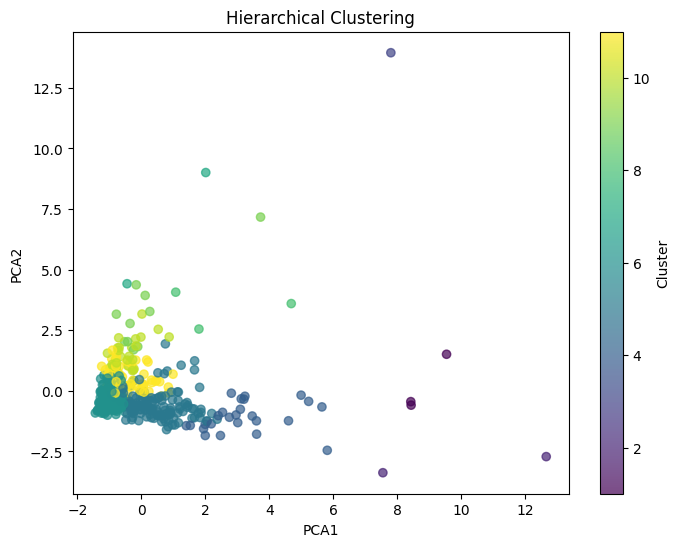

Cluster Summaries:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
1        2.000000  3.000000  34444.333333  55375.333333  49094.333333   
2        2.000000  2.500000  12341.000000  25588.500000  80039.000000   
3        1.000000  3.000000  36847.000000  43950.000000  20170.000000   
4        2.000000  2.461538   5305.884615  16095.038462  26960.500000   
5        1.685039  2.566929   5894.220472   8053.322835  11059.629921   
6        1.016949  2.502825   7876.254237   1902.627119   2534.536723   
7        1.000000  2.500000  22015.500000   9937.000000   7844.000000   
8        1.333333  3.000000  29309.666667  14238.000000  17059.333333   
9        1.000000  2.400000  62106.400000   6458.200000   7169.400000   
10       1.100000  2.666667  18163.433333   4352.700000   4219.533333   
11       1.288136  2.559322  26046.203390   4293.983051   5961.457627   

               Frozen  Detergen

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Load and Preprocess Data
def load_and_preprocess_data():
    """
    Loads and preprocesses the Wholesale Customers dataset.
    Scales the numerical features for clustering.
    """
    url = "Wholesale customers data.csv"
    data = pd.read_csv(url)
    features = data[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicatessen']]
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    return data, features_scaled, features

# Cluster Analysis Functions
def summarize_clusters(data, cluster_labels):
    data['Cluster'] = cluster_labels
    summary = data.groupby('Cluster').mean()
    print("Cluster Summaries:")
    print(summary)
    return summary

def plot_feature_distributions(data, feature, cluster_labels):
    data['Cluster'] = cluster_labels
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Cluster', y=feature, data=data)
    plt.title(f'{feature} Distribution Across Clusters')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.show()

def count_cluster_sizes(cluster_labels):
    cluster_sizes = pd.Series(cluster_labels).value_counts()
    print("Cluster Sizes:")
    print(cluster_sizes)
    return cluster_sizes

def analyze_feature_variance(data, cluster_labels):
    data['Cluster'] = cluster_labels
    variance = data.groupby('Cluster').var()
    print("Feature Variance Across Clusters:")
    print(variance)
    return variance

def pairwise_feature_plots(data, features, cluster_labels):
    data['Cluster'] = cluster_labels
    sns.pairplot(data, hue='Cluster', vars=features)
    plt.show()

def display_pca_loadings(pca, feature_columns):
    pca_components = pca.components_
    loadings = pd.DataFrame(pca_components, columns=feature_columns, index=[f'PC{i+1}' for i in range(len(pca_components))])
    print("PCA Component Loadings:")
    print(loadings)
    return loadings

# Visualization of Clusters Using PCA
def visualize_clusters_with_pca(features_scaled, cluster_labels, title="Clustering Visualization"):
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(features_scaled)
    plt.figure(figsize=(8, 6))
    plt.scatter(features_pca[:, 0], features_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
    plt.title(title)
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.colorbar(label='Cluster')
    plt.show()
    return pca

# Dendrogram Visualization for Hierarchical Clustering
def plot_dendrogram(linkage_matrix):
    plt.figure(figsize=(10, 7))
    dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=10)
    plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Sample Index or Cluster Size')
    plt.ylabel('Distance')
    plt.axhline(y=10, color='r', linestyle='--')
    plt.show()

# K-Means Clustering and Analysis
def analyze_kmeans(data, features_scaled):
    print("\n--- K-Means Clustering ---")
    labels_kmeans = KMeans(n_clusters=3, random_state=42).fit_predict(features_scaled)
    pca = visualize_clusters_with_pca(features_scaled, labels_kmeans, title="K-Means Clustering")
    summarize_clusters(data.copy(), labels_kmeans)
    count_cluster_sizes(labels_kmeans)
    analyze_feature_variance(data.copy(), labels_kmeans)
    return labels_kmeans, pca

# DBSCAN Clustering and Analysis
def analyze_dbscan(data, features_scaled):
    print("\n--- DBSCAN Clustering ---")
    labels_dbscan = DBSCAN(eps=1.5, min_samples=5).fit_predict(features_scaled)
    pca = visualize_clusters_with_pca(features_scaled, labels_dbscan, title="DBSCAN Clustering")
    count_cluster_sizes(labels_dbscan)
    return labels_dbscan, pca

# Hierarchical Clustering and Analysis
def analyze_hierarchical(data, features_scaled):
    print("\n--- Hierarchical Clustering ---")
    linkage_matrix = linkage(features_scaled, method='ward')
    plot_dendrogram(linkage_matrix)
    labels_hierarchical = fcluster(linkage_matrix, t=10, criterion='distance')
    pca = visualize_clusters_with_pca(features_scaled, labels_hierarchical, title="Hierarchical Clustering")
    summarize_clusters(data.copy(), labels_hierarchical)
    analyze_feature_variance(data.copy(), labels_hierarchical)
    return labels_hierarchical, pca

# Main Function
def main():
    # Load and preprocess data
    data, features_scaled, features = load_and_preprocess_data()

    # Analyze K-Means
    analyze_kmeans(data, features_scaled)

    # Analyze DBSCAN
    analyze_dbscan(data, features_scaled)

    # Analyze Hierarchical Clustering
    analyze_hierarchical(data, features_scaled)

if __name__ == "__main__":
    main()



--- DBSCAN Clustering ---

DBSCAN with eps=1.0, min_samples=5
Number of clusters: 1
Number of outliers: 47


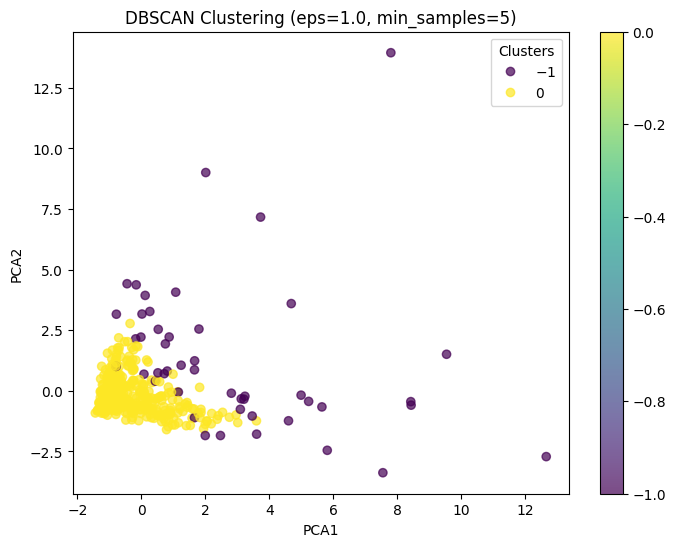


DBSCAN with eps=1.0, min_samples=10
Number of clusters: 1
Number of outliers: 54


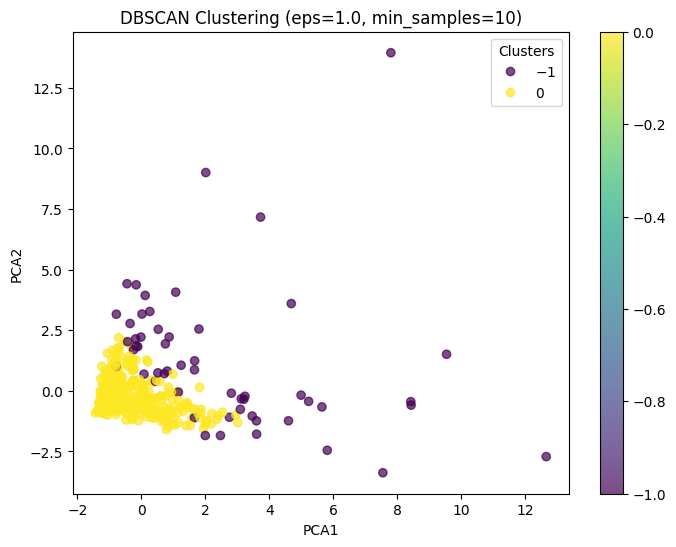


DBSCAN with eps=1.5, min_samples=5
Number of clusters: 1
Number of outliers: 27


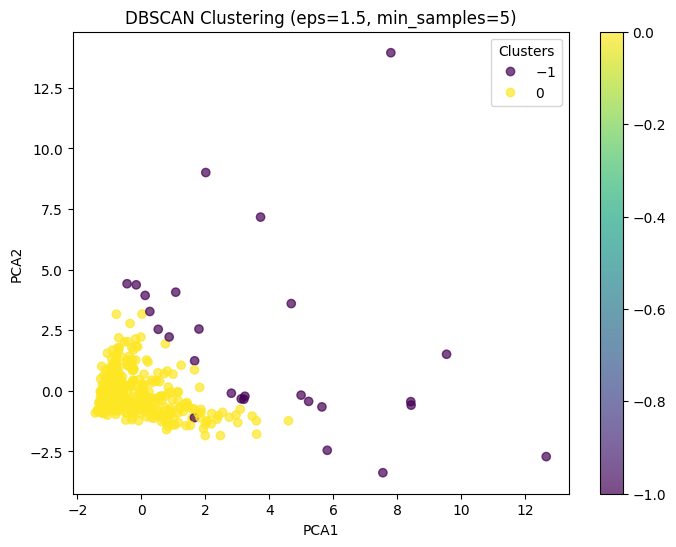


DBSCAN with eps=1.5, min_samples=10
Number of clusters: 1
Number of outliers: 29


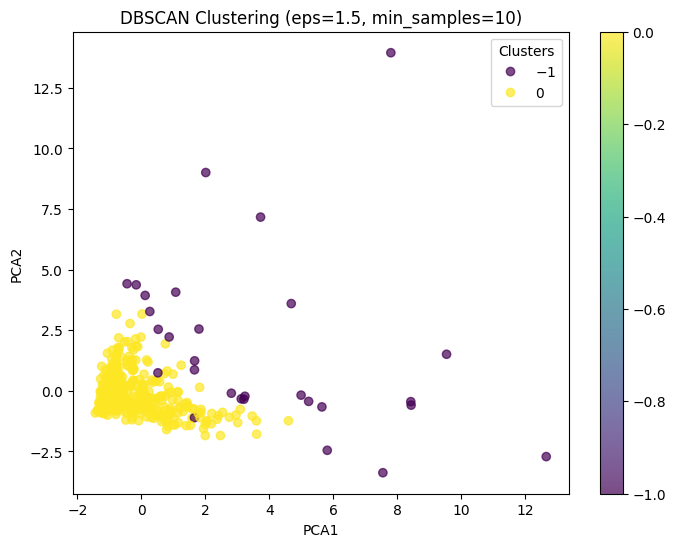


DBSCAN with eps=2.0, min_samples=5
Number of clusters: 1
Number of outliers: 13


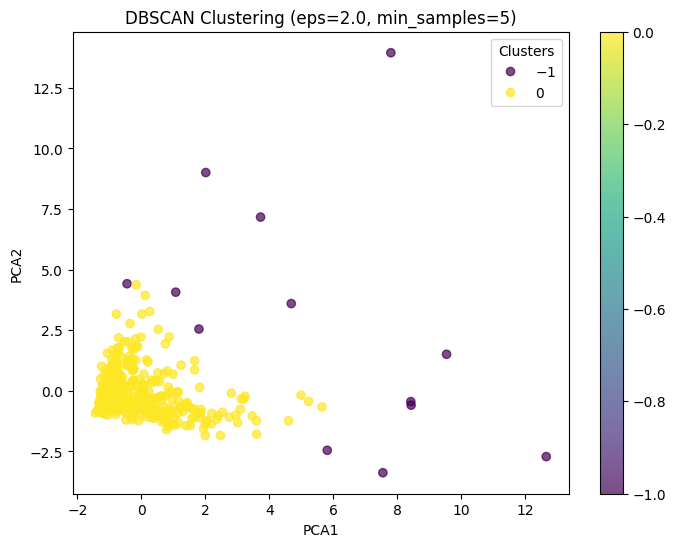


DBSCAN with eps=2.0, min_samples=10
Number of clusters: 1
Number of outliers: 17


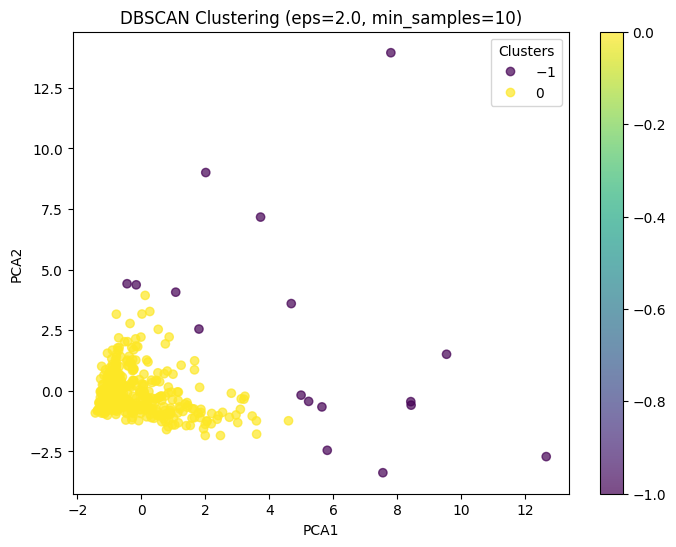


Removed 27 outliers

--- K-Means Clustering with n_clusters=3 ---


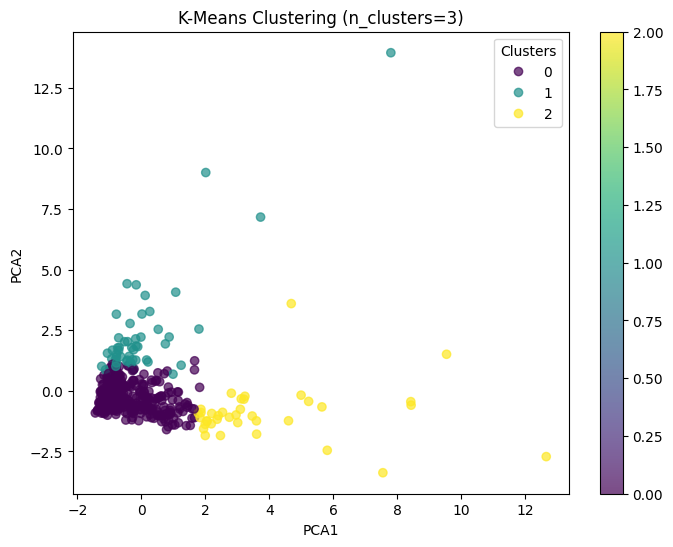

Cluster Summaries:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        1.282857  2.534286   8935.500000   4228.528571   5848.034286   
1        1.113208  2.698113  34540.113208   5860.358491   6122.622642   
2        2.000000  2.405405   8704.864865  20534.405405  30466.243243   

              Frozen  Detergents_Paper  Delicatessen  
Cluster                                               
0        2167.231429       1913.605714   1102.120000  
1        9841.735849        981.471698   3664.245283  
2        1932.621622      14758.837838   2459.351351  
Cluster Sizes:
0    350
1     53
2     37
Name: count, dtype: int64
Feature Variance Across Clusters:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        0.203430  0.610569  5.290787e+07  1.402581e+07  2.556984e+07   
1        0.102322  

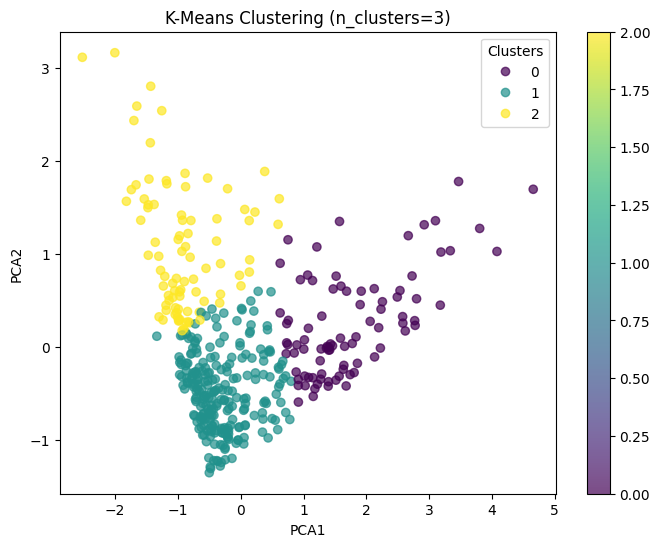

Cluster Summaries:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        1.919540  2.517241   4983.885057  10142.758621  16364.563218   
1        1.142259  2.535565   7323.962343   3050.246862   3818.866109   
2        1.149425  2.540230  27112.229885   3774.873563   4639.022989   

              Frozen  Detergents_Paper  Delicatessen  
Cluster                                               
0        1329.931034       7526.494253   1415.873563  
1        2396.004184       1029.142259    947.853556  
2        4407.827586        883.206897   1716.000000  
Cluster Sizes:
1    239
0     87
2     87
Name: count, dtype: int64
Feature Variance Across Clusters:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        0.074846  0.601443  2.272940e+07  2.274539e+07  3.500512e+07   
1        0.122534  

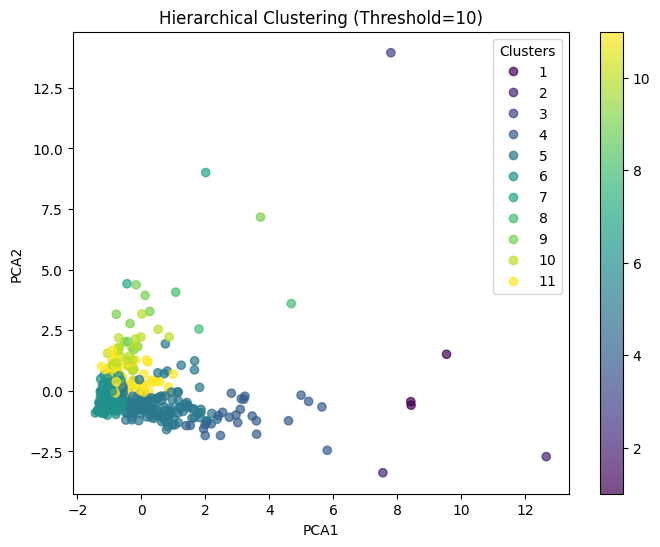

Cluster Summaries:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
1        2.000000  3.000000  34444.333333  55375.333333  49094.333333   
2        2.000000  2.500000  12341.000000  25588.500000  80039.000000   
3        1.000000  3.000000  36847.000000  43950.000000  20170.000000   
4        2.000000  2.461538   5305.884615  16095.038462  26960.500000   
5        1.685039  2.566929   5894.220472   8053.322835  11059.629921   
6        1.016949  2.502825   7876.254237   1902.627119   2534.536723   
7        1.000000  2.500000  22015.500000   9937.000000   7844.000000   
8        1.333333  3.000000  29309.666667  14238.000000  17059.333333   
9        1.000000  2.400000  62106.400000   6458.200000   7169.400000   
10       1.100000  2.666667  18163.433333   4352.700000   4219.533333   
11       1.288136  2.559322  26046.203390   4293.983051   5961.457627   

               Frozen  Detergen

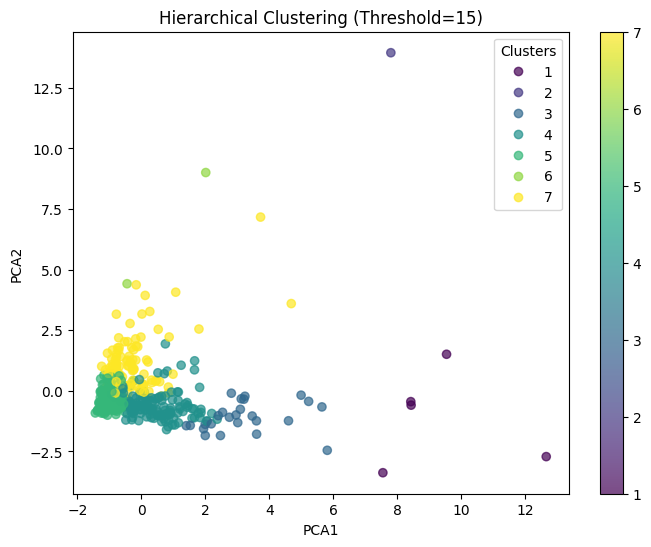

Cluster Summaries:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
1        2.000000  2.800000  25603.000000  43460.600000  61472.200000   
2        1.000000  3.000000  36847.000000  43950.000000  20170.000000   
3        2.000000  2.461538   5305.884615  16095.038462  26960.500000   
4        1.685039  2.566929   5894.220472   8053.322835  11059.629921   
5        1.016949  2.502825   7876.254237   1902.627119   2534.536723   
6        1.000000  2.500000  22015.500000   9937.000000   7844.000000   
7        1.205882  2.588235  27359.039216   4815.901961   5893.960784   

               Frozen  Detergents_Paper  Delicatessen  
Cluster                                                
1         2636.000000      29974.200000   2708.800000  
2        36534.000000        239.000000  47943.000000  
3         1567.153846      13301.615385   2185.000000  
4         1440.188976       4400.826772   1

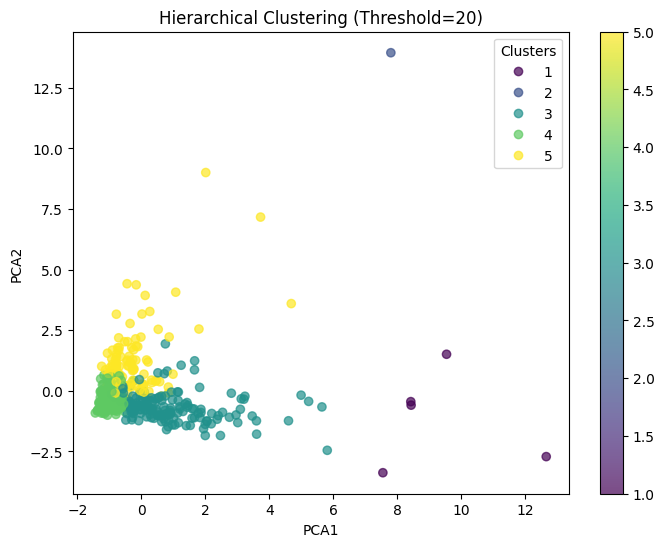

Cluster Summaries:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
1        2.000000  2.800000  25603.000000  43460.600000  61472.200000   
2        1.000000  3.000000  36847.000000  43950.000000  20170.000000   
3        1.738562  2.549020   5794.241830   9419.888889  13761.738562   
4        1.016949  2.502825   7876.254237   1902.627119   2534.536723   
5        1.201923  2.586538  27256.278846   4914.384615   5931.461538   

               Frozen  Detergents_Paper  Delicatessen  
Cluster                                                
1         2636.000000      29974.200000   2708.800000  
2        36534.000000        239.000000  47943.000000  
3         1461.764706       5913.379085   1577.607843  
4         2403.378531        507.135593    744.045198  
5         6277.769231       1184.971154   2272.942308  
Feature Variance Across Clusters:
          Channel    Region         Fresh  

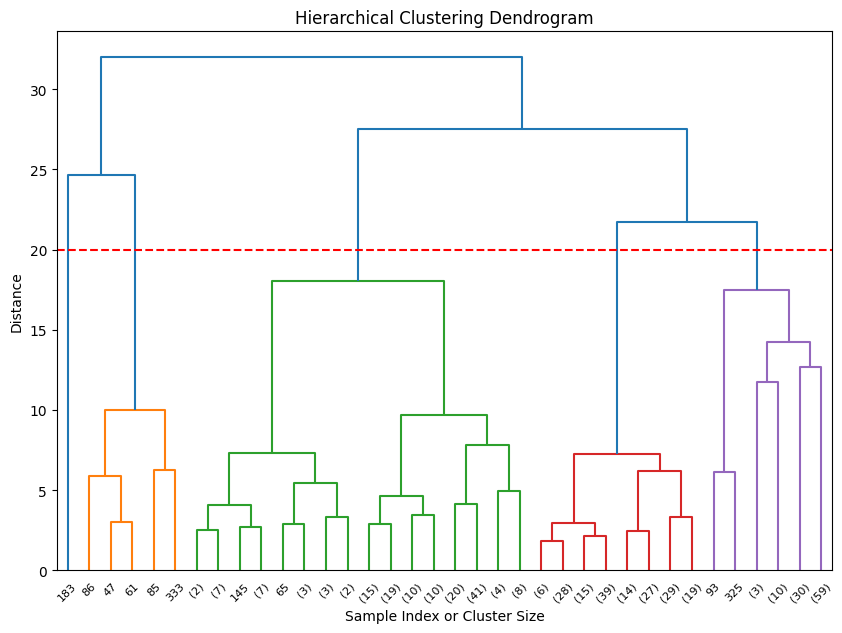

In [2]:
# wholesale_customer_clustering.py

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Load and Preprocess Data
def load_and_preprocess_data():
    """
    Loads and preprocesses the Wholesale Customers dataset.
    Scales the numerical features for clustering.
    """
    url = "Wholesale customers data.csv"
    data = pd.read_csv(url)
    # Exclude 'Channel' and 'Region'
    features = data.drop(['Channel', 'Region'], axis=1)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    return data, features_scaled, features

# Cluster Analysis Functions
def summarize_clusters(data, cluster_labels):
    data['Cluster'] = cluster_labels
    summary = data.groupby('Cluster').mean()
    print("Cluster Summaries:")
    print(summary)
    return summary

def count_cluster_sizes(cluster_labels):
    cluster_sizes = pd.Series(cluster_labels).value_counts()
    print("Cluster Sizes:")
    print(cluster_sizes)
    return cluster_sizes

def analyze_feature_variance(data, cluster_labels):
    data['Cluster'] = cluster_labels
    variance = data.groupby('Cluster').var()
    print("Feature Variance Across Clusters:")
    print(variance)
    return variance

def visualize_clusters_with_pca(features_scaled, cluster_labels, title="Clustering Visualization"):
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(features_scaled)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1],
                          c=cluster_labels, cmap='viridis', alpha=0.7)
    plt.title(title)
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.colorbar()
    plt.show()
    return pca

def plot_dendrogram(linkage_matrix, threshold=None):
    plt.figure(figsize=(10, 7))
    dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=threshold)
    plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Sample Index or Cluster Size')
    plt.ylabel('Distance')
    if threshold:
        plt.axhline(y=threshold, color='r', linestyle='--')
    plt.show()

# Outlier Detection and Removal using DBSCAN
def analyze_dbscan(data, features_scaled):
    print("\n--- DBSCAN Clustering ---")
    # Experiment with different eps and min_samples
    eps_values = [1.0, 1.5, 2.0]
    min_samples_values = [5, 10]

    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels_dbscan = dbscan.fit_predict(features_scaled)
            n_outliers = np.sum(labels_dbscan == -1)
            n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
            print(f"\nDBSCAN with eps={eps}, min_samples={min_samples}")
            print(f"Number of clusters: {n_clusters}")
            print(f"Number of outliers: {n_outliers}")
            # Visualize clusters and outliers
            visualize_clusters_with_pca(features_scaled, labels_dbscan,
                                        title=f"DBSCAN Clustering (eps={eps}, min_samples={min_samples})")
    # Use default parameters for further analysis
    dbscan = DBSCAN(eps=1.5, min_samples=5)
    labels_dbscan = dbscan.fit_predict(features_scaled)
    return labels_dbscan

def remove_outliers(data, features_scaled, labels_dbscan):
    data_dbscan = data.copy()
    data_dbscan['Cluster'] = labels_dbscan
    # Filter out outliers labeled as -1
    data_cleaned = data_dbscan[data_dbscan['Cluster'] != -1].reset_index(drop=True)
    features_cleaned = features_scaled[data_dbscan['Cluster'] != -1]
    print(f"\nRemoved {len(data) - len(data_cleaned)} outliers")
    return data_cleaned, features_cleaned

# K-Means Clustering and Analysis
def analyze_kmeans(data, features_scaled, n_clusters_list=[3]):
    from sklearn.cluster import KMeans
    results = {}
    for n_clusters in n_clusters_list:
        print(f"\n--- K-Means Clustering with n_clusters={n_clusters} ---")
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels_kmeans = kmeans.fit_predict(features_scaled)
        pca = visualize_clusters_with_pca(features_scaled, labels_kmeans,
                                          title=f"K-Means Clustering (n_clusters={n_clusters})")
        summarize_clusters(data.copy(), labels_kmeans)
        count_cluster_sizes(labels_kmeans)
        analyze_feature_variance(data.copy(), labels_kmeans)
        results[n_clusters] = labels_kmeans
    return results

# Hierarchical Clustering and Analysis
def analyze_hierarchical(data, features_scaled, method='ward'):
    print(f"\n--- Hierarchical Clustering using {method.capitalize()} Linkage ---")
    linkage_matrix = linkage(features_scaled, method=method)
    thresholds = [10, 15, 20]
    for threshold in thresholds:
        print(f"\nCutting dendrogram at threshold {threshold}")
        labels_hierarchical = fcluster(linkage_matrix, t=threshold, criterion='distance')
        visualize_clusters_with_pca(features_scaled, labels_hierarchical,
                                    title=f"Hierarchical Clustering (Threshold={threshold})")
        summarize_clusters(data.copy(), labels_hierarchical)
        analyze_feature_variance(data.copy(), labels_hierarchical)
    # Plot dendrogram with last threshold
    plot_dendrogram(linkage_matrix, threshold=thresholds[-1])
    return labels_hierarchical

# Main Function
def main():
    # Load and preprocess data
    data, features_scaled, features = load_and_preprocess_data()

    # Analyze DBSCAN and remove outliers
    labels_dbscan = analyze_dbscan(data, features_scaled)
    data_cleaned, features_cleaned = remove_outliers(data, features_scaled, labels_dbscan)

    # Analyze K-Means on Original Data
    analyze_kmeans(data, features_scaled, n_clusters_list=[3])

    # Analyze K-Means on Cleaned Data
    analyze_kmeans(data_cleaned, features_cleaned, n_clusters_list=[3])

    # Analyze Hierarchical Clustering
    analyze_hierarchical(data, features_scaled, method='ward')

if __name__ == "__main__":
    main()

# Clustering Analysis

## 1. DBSCAN

### a. How many outliers were detected in each dataset? What do these outliers represent?

- **eps=1.0, min_samples=5:**
  - Number of clusters: 1
  - Number of outliers: 47

- **eps=1.5, min_samples=5:**
  - Number of clusters: 1
  - Number of outliers: 27

- **eps=2.0, min_samples=5:**
  - Number of clusters: 1
  - Number of outliers: 13

**Outlier Analysis:**

- With `eps=1.5` and `min_samples=5`, 27 outliers were identified out of 440 entries.
- These outliers likely represent wholesale customers with atypical purchasing behaviors, such as unusually high orders in specific categories like 'Fresh' or 'Frozen' or low consumption across all categories.
- Outliers might be special cases like large hotel chains, specialized retailers, or data entry errors.

### b. How did changing eps and min_samples affect the clustering results?

**Effect of eps:**

- **Decrease in eps (from 2.0 to 1.0):**
  - Number of outliers increased from 13 to 47.
  - Clusters remained at 1, indicating that most data points were being classified as outliers.

- **Increase in eps (from 1.0 to 2.0):**
  - Outliers decreased, more points were included in the main cluster.

**Effect of min_samples:**

- Changing `min_samples` from 5 to 10 had a smaller effect compared to changing `eps`.
- Slight increase in outliers when increasing `min_samples`.

**Observation:**

- Dataset forms a single dense cluster with varying numbers of outliers depending on `eps`.
- Optimal `eps` appears to be around 1.5, balancing cluster density and outlier detection.

## 2. K-Means

### a. How did removing outliers affect the K-Means clusters?

**Before Removing Outliers (Original Data):**

- `n_clusters=3`:
  - Cluster Sizes: 350, 53, 37
  - High variance in 'Fresh' and 'Frozen' categories within clusters.
  - Cluster Summaries Indicate:
    - Clusters may include outliers affecting mean values and variances.

**After Removing Outliers (Cleaned Data):**

- Removed 27 Outliers
- `n_clusters=3`:
  - Cluster Sizes: 239, 87, 87
  - Clusters are more balanced in size.
  - Variance within clusters decreased notably.

**Observation:**

- Clusters after outlier removal are more homogeneous and representative of typical customer segments.
- Clusters exhibit clearer differences in purchasing behaviors.

### b. Which n_clusters value produced the most meaningful clusters?

- **n_clusters=3:**
  - After Outlier Removal:
    - Clusters are balanced in size (239, 87, 87).
    - Clusters differentiate customers based on their purchasing volumes in different categories.
    - Cluster Insights:
      - Cluster 0: Customers with higher 'Milk' and 'Grocery' spending.
      - Cluster 1: Small retailers with lower spending across categories.
      - Cluster 2: Customers with high 'Fresh' spending.

**Conclusion:**

- `n_clusters=3` was effective in segmenting the customers into distinct groups with meaningful differences in purchasing behavior.

## 3. Hierarchical Clustering

### a. How does the dendrogram reveal relationships between clusters?

**Using Ward Linkage:**

- **Threshold = 10:**
  - Multiple clusters are formed, each with distinct purchasing profiles.
  - For example:
    - Cluster 1: High 'Fresh' and 'Grocery' spending.
    - Cluster 3: Extremely high 'Frozen' and 'Delicatessen' spending.

- **Threshold = 15:**
  - Clusters merge, reducing the number of clusters.
  - New clusters combine customers with similar but slightly broader purchasing behaviors.

- **Threshold = 20:**
  - Further merges occur, clusters become larger and less specific.

**Dendrogram Insights:**

- The height at which branches merge indicates the dissimilarity between clusters.
- Clusters merging at lower heights are more similar, while those merging at higher heights are more dissimilar.

### b. What happens when the threshold for cutting the dendrogram is too high or too low?

- **Threshold Too High:**
  - High thresholds lead to fewer clusters, possibly merging distinct customer types into broad clusters.
  - May overlook important differences in purchasing behavior.

- **Threshold Too Low:**
  - Low thresholds result in numerous clusters, complicating interpretation and practical application.
  - Clusters may represent minor variations rather than meaningful differences.

**Optimal Threshold Selection:**

- The dendrogram helps identify an appropriate threshold by visualizing where large jumps in linkage distances occur.
- These jumps indicate natural divisions in the data.
- Choosing thresholds at these points balances the granularity and interpretability of clusters.

## 4. General Comparison

### a. Which clustering method worked best for each dataset? Why?

**Best Method: Hierarchical Clustering with Ward Linkage and K-Means after Outlier Removal**

**Reasons:**

- **Hierarchical Clustering:**
  - Revealed meaningful clusters at different thresholds.
  - Dendrogram provided insights into the relationships between customers.
  - Allowed for exploration of clusters at multiple levels of granularity.

- **K-Means:**
  - After removing outliers, K-Means produced balanced and interpretable clusters.
  - `n_clusters=3` effectively segmented customers based on purchasing patterns.

- **DBSCAN:**
  - Useful for identifying outliers.
  - Tended to form a single cluster with varying numbers of outliers, not ideal for clustering in this dataset.

### b. How would you use these clusters in a real-world scenario (e.g., marketing)?

**Inventory and Supply Chain Management:**

- Adjust inventory levels based on the purchasing patterns of each cluster.
- For clusters with high 'Fresh' product consumption, ensure a reliable supply of perishable goods.

**Sales Strategy Development:**

- Tailor sales approaches for different clusters.
- Cluster 0 (High Milk and Grocery Spending):
  - Offer bundled deals or volume discounts on dairy and grocery products.
- Cluster 2 (High Fresh Spending):
  - Emphasize the quality and freshness of products, possibly introduce new fresh offerings.

**Business Expansion and Partnerships:**

- Identify potential areas for business growth by analyzing the needs of different clusters.
- Establish partnerships with suppliers or distributors catering to specific clusters.

**Risk Management:**

- Monitor clusters with atypical purchasing behaviors for potential risks, such as overstocking or cash flow issues.

#**Comparison of Effectiveness of Each Clustering Method for Each Dataset:**

- **DBSCAN:**
  - Useful for identifying outliers.
  - Formed a single cluster, indicating that density-based clustering may not be suitable for this dataset.
  - Adjusting parameters did not significantly improve clustering results.

- **K-Means Clustering:**
  - Effective after outlier removal.
  - Clusters are balanced and meaningful.
  - Provided practical segmentation for operational and marketing strategies.

- **Hierarchical Clustering:**
  - Highly effective with Ward linkage.
  - Dendrogram provided insights into customer relationships.
  - Allowed for flexible clustering at different levels of detail.

**Conclusion:**

- Hierarchical Clustering and K-Means (post-outlier removal) were both effective, with Hierarchical Clustering providing deeper insights into the data structure.
